In [3]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Make plots look nice
sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Cell 2: Load Data
from sklearn.datasets import load_wine

# Load the wine dataset
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0, 1, 2 (Three types of wine)

# For simplicity, let's make it a BINARY problem (Good vs Bad)
# Let's say Class 0 and 1 are "Good" (1), and Class 2 is "Bad" (0)
df['target_binary'] = df['target'].apply(lambda x: 1 if x < 2 else 0)

print("First 5 rows of our dataset:")
print(df.head())

# Check the balance of our new binary target
print("\nCount of Good (1) vs Bad (0) wines:")
print(df['target_binary'].value_counts())

First 5 rows of our dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  

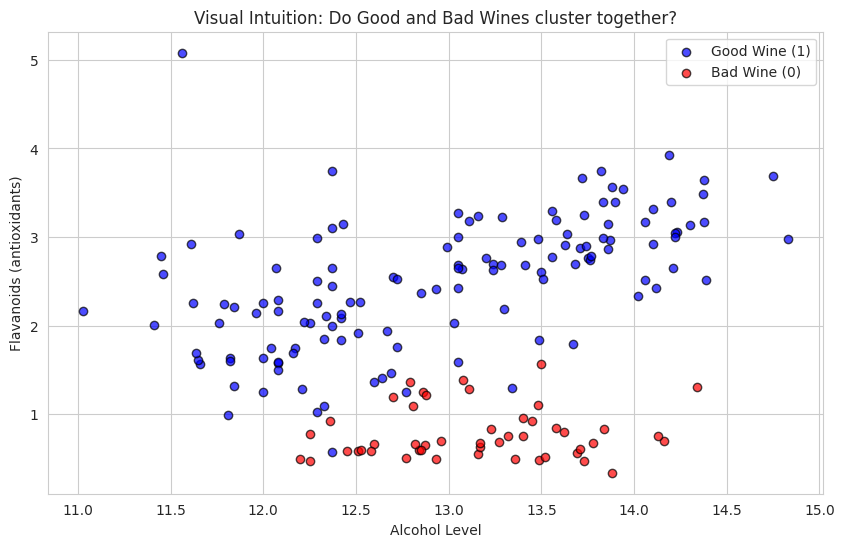

Notice how Good wines (Blue) cluster in the top-right, and Bad wines (Red) cluster in the bottom-left. KNN will use this logic!


In [5]:
# Cell 3: Visualizing the data
plt.figure(figsize=(10, 6))

# Plot only Good wines (Blue)
good = df[df['target_binary'] == 1]
plt.scatter(good['alcohol'], good['flavanoids'], 
            color='blue', label='Good Wine (1)', alpha=0.7, edgecolors='k')

# Plot only Bad wines (Red)
bad = df[df['target_binary'] == 0]
plt.scatter(bad['alcohol'], bad['flavanoids'], 
            color='red', label='Bad Wine (0)', alpha=0.7, edgecolors='k')

plt.xlabel('Alcohol Level')
plt.ylabel('Flavanoids (antioxidants)')
plt.title('Visual Intuition: Do Good and Bad Wines cluster together?')
plt.legend()
plt.show()

print("Notice how Good wines (Blue) cluster in the top-right, and Bad wines (Red) cluster in the bottom-left. KNN will use this logic!")

In [6]:
# Cell 4: Define X and y
X = df.drop(['target', 'target_binary'], axis=1)  # All chemical features
y = df['target_binary']  # Good (1) or Bad (0)

print(f"We have {X.shape[1]} features (columns) to predict from.")
print(f"We have {X.shape[0]} total wines in our dataset.")

We have 13 features (columns) to predict from.
We have 178 total wines in our dataset.


In [7]:
# Cell 5: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42, 
                                                    stratify=y)

print(f"Training set size: {len(X_train)} wines")
print(f"Testing set size: {len(X_test)} wines")

Training set size: 124 wines
Testing set size: 54 wines


In [8]:
# Cell 6: Scaling the Data
scaler = StandardScaler()

# Fit the scaler on the TRAINING data only (to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the SAME scaler
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to view (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Original Training Data (first 5 rows):")
print(X_train.head())
print("\nScaled Training Data (first 5 rows) - Notice all values are now between ~ -2 and 2:")
print(X_train_scaled_df.head())

Original Training Data (first 5 rows):
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
131    12.88        2.99  2.40               20.0      104.0           1.30   
9      13.86        1.35  2.27               16.0       98.0           2.98   
169    13.40        4.60  2.86               25.0      112.0           1.98   
104    12.51        1.73  1.98               20.5       85.0           2.20   
149    13.08        3.90  2.36               21.5      113.0           1.41   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
131        1.22                  0.24             0.83             5.40  0.74   
9          3.15                  0.22             1.85             7.22  1.01   
169        0.96                  0.27             1.11             8.50  0.67   
104        1.92                  0.32             1.48             2.94  1.04   
149        1.39                  0.34             1.14             9.40  0.57   


In [9]:
# Cell 7: Initialize and Train KNN
# We'll start with K=5 (ask 5 closest wines)
knn_model = KNeighborsClassifier(n_neighbors=5)

# This is where it "memorizes" the training data
knn_model.fit(X_train_scaled, y_train)

print("KNN model has memorized the training data!")

KNN model has memorized the training data!


In [10]:
# Cell 8: Predictions
y_pred = knn_model.predict(X_test_scaled)

# Let's look at the first 10 predictions vs the actual answers
predictions_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})
print("First 10 Predictions vs Reality:")
print(predictions_df)
print("\n(0 = Bad Wine, 1 = Good Wine)")

First 10 Predictions vs Reality:
   Actual  Predicted
0       1          1
1       0          0
2       1          1
3       1          1
4       1          1
5       0          0
6       0          0
7       1          1
8       1          0
9       1          1

(0 = Bad Wine, 1 = Good Wine)


 Model Accuracy: 96.30%

 Classification Report (Precision/Recall):
              precision    recall  f1-score   support

    Bad Wine       0.88      1.00      0.94        15
   Good Wine       1.00      0.95      0.97        39

    accuracy                           0.96        54
   macro avg       0.94      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



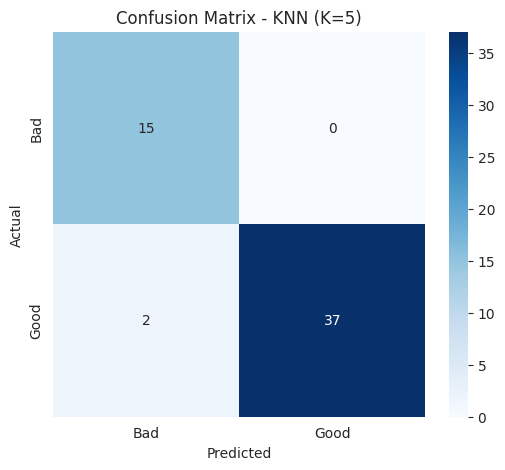

In [12]:
# Cell 9: Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f" Model Accuracy: {accuracy * 100:.2f}%")
print("\n Classification Report (Precision/Recall):")
print(classification_report(y_test, y_pred, target_names=['Bad Wine', 'Good Wine']))

# Plot the Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN (K=5)')
plt.show()

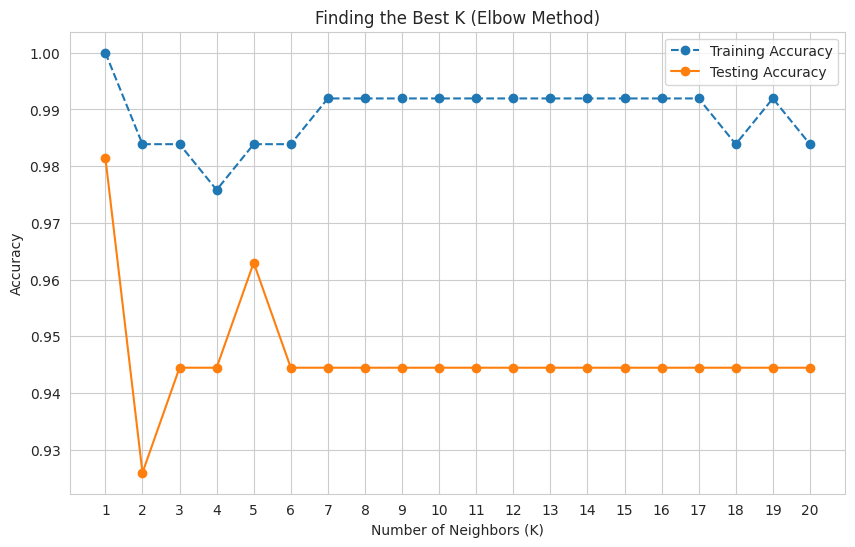

 The best K value is: 1 with 98.15% test accuracy!


In [14]:
# Cell 10: Elbow Method to find optimal K
k_values = range(1, 21)
test_accuracies = []
train_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    # Test accuracy
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    test_accuracies.append(test_acc)
    
    # Train accuracy (to check for overfitting)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    train_accuracies.append(train_acc)

# Plot the results
plt.figure(figsize=(10,6))
plt.plot(k_values, train_accuracies, label='Training Accuracy', marker='o', linestyle='--')
plt.plot(k_values, test_accuracies, label='Testing Accuracy', marker='o', linestyle='-')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('Finding the Best K (Elbow Method)')
plt.legend()
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Find the best K
best_k = k_values[test_accuracies.index(max(test_accuracies))]
print(f" The best K value is: {best_k} with {max(test_accuracies)*100:.2f}% test accuracy!")

In [ ]:
# Cell 11: Predicting a New Custom Wine
# Step 1: Retrain the model with the best K we found
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_scaled, y_train)

# Step 2: Create a fictional new wine (values based on real feature ranges)
# Features: Alcohol, Malic_Acid, Ash, Ash_Alkalinity, Magnesium, Total_Phenols, Flavanoids, 
#           Nonflavanoid_Phenols, Proanthocyanins, Color_Intensity, Hue, OD280, Proline
new_wine = [[14.5,  1.8,  2.4,  16.0,  100,  2.8,  3.2,  0.3,  1.8,  5.5,  1.0,  3.5,  750]]

# Step 3: Scale this new wine using the SAME scaler (crucial!)
new_wine_scaled = scaler.transform(new_wine)

# Step 4: Predict!
prediction = best_model.predict(new_wine_scaled)
probability = best_model.predict_proba(new_wine_scaled)

if prediction[0] == 1:
    print(" Result: This is a GOOD quality wine!")
else:
    print(" Result: This is a BAD quality wine.")

print(f"\nConfidence Scores:")
print(f"  - Chance of being Bad: {probability[0][0]*100:.2f}%")
print(f"  - Chance of being Good: {probability[0][1]*100:.2f}%")

🍷 Result: This is a GOOD quality wine!

Confidence Scores:
  - Chance of being Bad: 0.00%
  - Chance of being Good: 100.00%


/home/vboxuser/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
